In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer


from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.load_state_dict(torch.load('runs/newbase/dim64_seed0/model_weights.pth'))
model.to(device);

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [4]:
model.core

Stacked2dCore(
  (_input_weights_regularizer): LaplaceL2norm(
    (laplace): Laplace()
  )
  (features): Sequential(
    (layer0): Sequential(
      (conv): Conv2d(4, 64, kernel_size=(11, 11), stride=(1, 1), bias=False)
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
      (nonlin): AdaptiveELU()
    )
    (layer1): Sequential(
      (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
      (nonlin): AdaptiveELU()
    )
    (layer2): Sequential(
      (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
      (nonlin): AdaptiveELU()
    )
    (layer3): Sequential(
      (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=False,

In [5]:
[k for k, v in model.named_parameters()]

['core.features.layer0.conv.weight',
 'core.features.layer0.norm.weight',
 'core.features.layer0.norm.bias',
 'core.features.layer1.conv.weight',
 'core.features.layer1.conv.bias',
 'core.features.layer1.norm.weight',
 'core.features.layer1.norm.bias',
 'core.features.layer2.conv.weight',
 'core.features.layer2.conv.bias',
 'core.features.layer2.norm.weight',
 'core.features.layer2.norm.bias',
 'core.features.layer3.conv.weight',
 'core.features.layer3.conv.bias',
 'readout.23343-5-17.adaptive_neuron_reg_coefs',
 'readout.23343-5-17.sigma',
 'readout.23343-5-17._features',
 'readout.23343-5-17.bias',
 'readout.23343-5-17.mu_transform.0.weight',
 'readout.23343-5-17.mu_transform.0.bias',
 'readout.23343-5-17.mu_transform.2.weight',
 'readout.23343-5-17.mu_transform.2.bias',
 'readout.23964-4-22.adaptive_neuron_reg_coefs',
 'readout.23964-4-22.sigma',
 'readout.23964-4-22._features',
 'readout.23964-4-22.bias',
 'readout.23964-4-22.mu_transform.0.weight',
 'readout.23964-4-22.mu_transfor

In [3]:
embeddings = model.readout[key].features.data.squeeze().cpu().T

NameError: name 'key' is not defined

In [6]:
model.eval()

pred_responses = []
feature_maps = []
behavs = []

for key in data_keys:
    single_maps = []
    single_behavs = []

    for batch in dataloaders['validation'][key]:
        img, _, behav, pupil = batch
        #img, _, pupil = batch
        
        pred = model(img, data_key=key, pupil_center=pupil).detach().cpu()
        pred_responses.append(pred)
        
        feature_map = model.core(img).detach().cpu()
        single_maps.append(feature_map)
        single_behavs.append(behav)

    feature_maps.append(torch.cat(single_maps))
    behavs.append(torch.cat(single_behavs))

#pred_responses = torch.cat(pred_responses).T  # (num_neurons, num_images)

2.51 	 1.0
2.81 	 1.01
4.13 	 1.0
2.15 	 1.0
2.41 	 1.01
2.15 	 1.0

0.16 	 0.95
0.14 	 1.0
0.13 	 1.02
0.16 	 0.98
0.15 	 0.98
0.06 	 0.99

-0.19 	 1.0
0.03 	 0.98
-0.48 	 0.99
-0.0 	 1.06
-0.22 	 1.04
-0.03 	 1.02


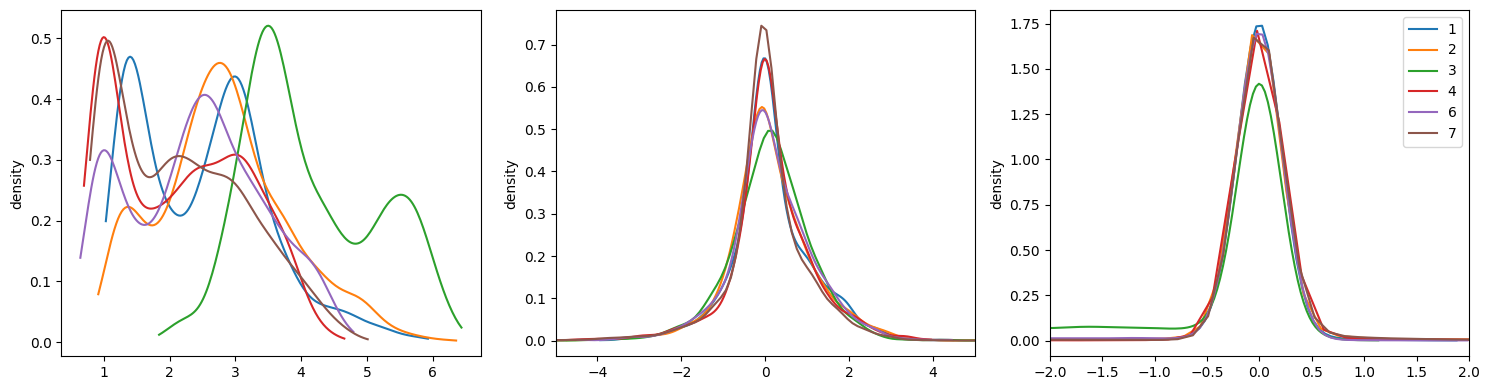

In [50]:
import numpy as np
from scipy import stats

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for num_animal, behav in enumerate(behavs):
    if num_animal == 4: continue
    data = behav[:, 0].cpu().numpy()
    print(data.mean().round(2), '\t', data.std().round(2))
    
    # Calculate KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    
    axs[0].plot(x_range, density, label=num_animal + 1)

axs[0].set_ylabel('density')
print()

for num_animal, behav in enumerate(behavs):
    if num_animal == 4: continue
    data = behav[:, 1].cpu().numpy()
    print(data.mean().round(2), '\t', data.std().round(2))
    
    # Calculate KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    
    axs[1].plot(x_range, density, label=num_animal + 1)
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel('density')
print()

for num_animal, behav in enumerate(behavs):
    if num_animal == 4: continue
    data = behav[:, 2].cpu().numpy()
    print(data.mean().round(2), '\t', data.std().round(2))

    # Calculate KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    
    axs[2].plot(x_range, density, label=num_animal + 1)
axs[2].set_xlim(-2, 2)
axs[2].set_ylabel('density')

plt.legend()
plt.tight_layout()
plt.show()

In [6]:
resp_cor = torch.corrcoef(pred_responses)

In [7]:
norm = torch.norm(embeddings, dim=1)
normalized_embeds = embeddings / norm[:, None]
cosine_sim = (
    (normalized_embeds[None, :, :] * normalized_embeds[:, None, :])
    .sum(dim=-1)
)

In [8]:
i, j = np.tril_indices(resp_cor.shape[0], k=-1)
resp_cor = resp_cor[i, j]
dists = dists[i, j]
cosine_sim = cosine_sim[i, j]

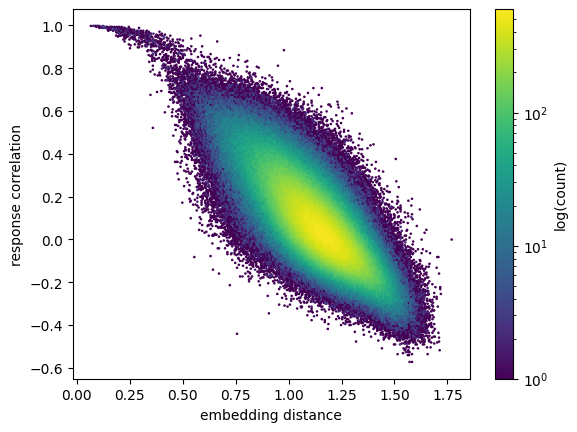

In [11]:
idcs = np.random.permutation(resp_cor.shape[0])[:2000000]
plt.hexbin(
    dists[idcs],
    resp_cor[idcs],
    gridsize=300,
    bins='log'   # log density is crucial
)
plt.colorbar(label='log(count)')
plt.xlabel('embedding distance')
plt.ylabel('response correlation')
plt.savefig('plots/response_corr_vs_emb_dist.png')
plt.show()

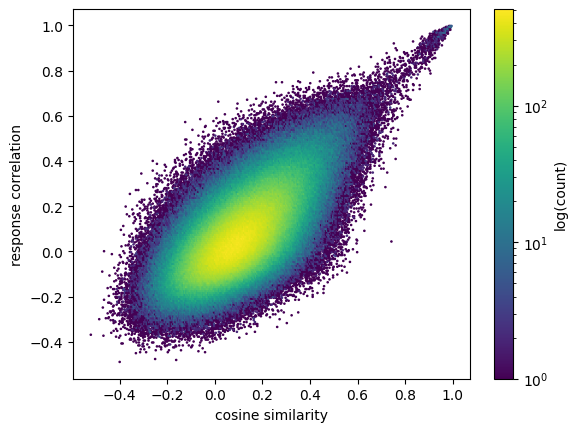

In [10]:
idcs = np.random.permutation(resp_cor.shape[0])[:2000000]
plt.hexbin(
    cosine_sim[idcs],
    resp_cor[idcs],
    gridsize=300,
    bins='log'   # log density is crucial
)
plt.colorbar(label='log(count)')
plt.xlabel('cosine similarity')
plt.ylabel('response correlation')
plt.savefig('plots/response_corr_vs_cosine_sim.png')
plt.show()

In [24]:
torch.zeros(10).unsqueeze(0) @ torch.zeros(10).unsqueeze(1)

tensor([[0.]])

In [11]:
cosine_sim0 = cosine_sim - cosine_sim.mean()
resp_cor0 = resp_cor - resp_cor.mean()
correlation = (
    cosine_sim0 @ resp_cor0) / (torch.norm(cosine_sim0) * torch.norm(resp_cor0)
)
print(correlation)

tensor(0.6636)


In [11]:
def plot_eigvals(model_path, label, colors):
    cp = torch.load(model_path)
    
    X = torch.cat([
        param.cpu().squeeze().T 
        for name, param in cp.items() if '_features' in name
    ])

    Xc = X - X.mean(dim=0)

    _, S, _ = torch.linalg.svd(Xc, full_matrices=False)
    eigvals = (S**2) / (Xc.shape[0] - 1)
    eigvals /= eigvals.sum()

    color = colors[label]
    plt.plot(np.arange(len(eigvals)) + 1, eigvals, ls='-', label=label, c=color)
    plt.xlabel('eigenvalues')
    plt.ylabel('magnitude')

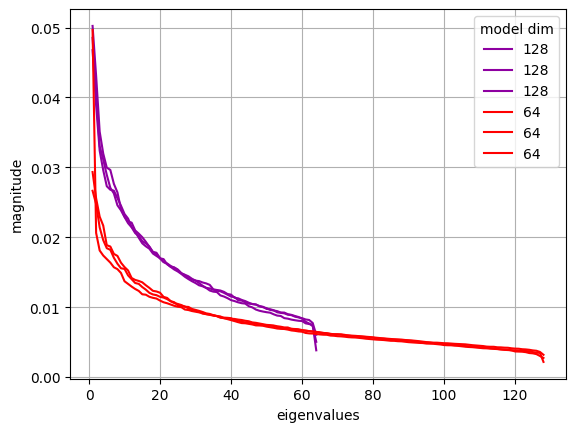

In [13]:
'''
model_paths = [
    'runs/base/exp0/model_weights.pth',
    'runs/base/exp1/model_weights.pth',
    'runs/base/exp2/model_weights.pth',
    'runs/base/exp3/model_weights.pth',
    'runs/base/exp4/model_weights.pth',
    'runs/base/exp5/model_weights.pth',
    'runs/base/exp29/model_weights.pth', 
    'runs/base/exp30/model_weights.pth', 
    'runs/base/exp31/model_weights.pth', 
    'runs/base/exp32/model_weights.pth', 
    'runs/base/exp33/model_weights.pth', 
    'runs/base/exp34/model_weights.pth', 
]
'''

model_paths = [
    'runs/newbase/dim64_seed0/model_weights.pth', 
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth', 
    'runs/newbase/dim128_seed0/model_weights.pth', 
    'runs/newbase/dim128_seed42/model_weights.pth',
    'runs/newbase/dim128_seed123/model_weights.pth',
]

labels = [
    128, 128, 128, 64, 64, 64,# 48, 48, 48, 32, 32, 32
]
colors = {
    128: "#8E00A1",
    64: "#FF0000",
    48: "#40CA00",
    32: "#000DCA",
}
[plot_eigvals(path, l, colors) for path, l in zip(model_paths, labels)]
plt.legend(title='model dim')
plt.grid()
plt.savefig('plots/eigvals.png')
plt.show()

In [7]:
cat_feature_maps = torch.cat(feature_maps)
channels = cat_feature_maps.permute(1, 0, 2, 3).flatten(1, 3)
#channels = feature_maps[0].permute(1, 0, 2, 3).flatten(1, 3)

X = channels
Xc = X - X.mean(dim=1, keepdim=True)
cov = Xc @ Xc.T / (X.shape[1] - 1)

std = Xc.std(dim=1, keepdim=True)
corr = cov / (std @ std.T + 1e-6)

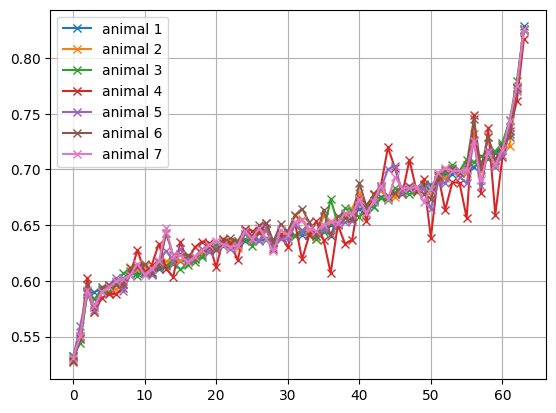

In [56]:
# vars 
order = feature_maps[0].permute(1, 0, 2, 3).flatten(1, 3).var(dim=1).argsort()

for i in range(7):
    vals = feature_maps[i].permute(1, 0, 2, 3).flatten(1, 3).var(dim=1)[order]
    plt.plot(range(len(vals)), vals, label=f'animal {i + 1}', marker='x')
#plt.plot(range(len(eigvals)), eigvals, label='readout eigvecs', marker='x')
plt.grid(True)
#plt.yscale('log')
plt.legend()

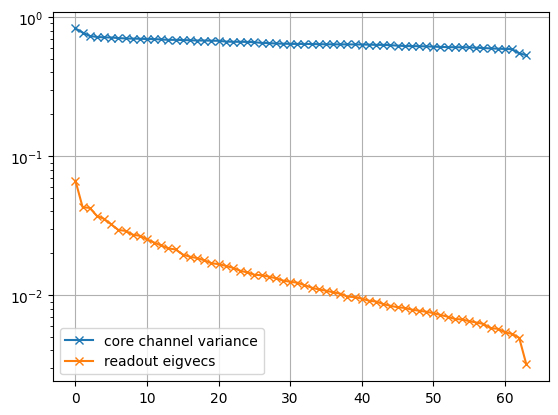

In [41]:
# vars 
vals, _ = cov.diag().sort()
vals = vals.flip(0)

# eigvecs
X = embeddings
Xc = X - X.mean(dim=0)

_, S, _ = torch.linalg.svd(Xc, full_matrices=False)
eigvals = (S**2) / (Xc.shape[0] - 1)
eigvals /= eigvals.sum()
(eigvals > 1e-4).sum()

plt.plot(range(len(eigvals)), vals, label='core channel variance', marker='x')
plt.plot(range(len(eigvals)), eigvals, label='readout eigvecs', marker='x')
plt.grid(True)
plt.yscale('log')
plt.legend()

In [8]:
used = cov.diag() > 0.1
print(used.sum())

filtered_cov = cov[used][:, used]
filtered_corr = corr[used][:, used]

tensor(64)


/tmp/ipykernel_444199/3122104288.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = np.abs(data) < 0.3


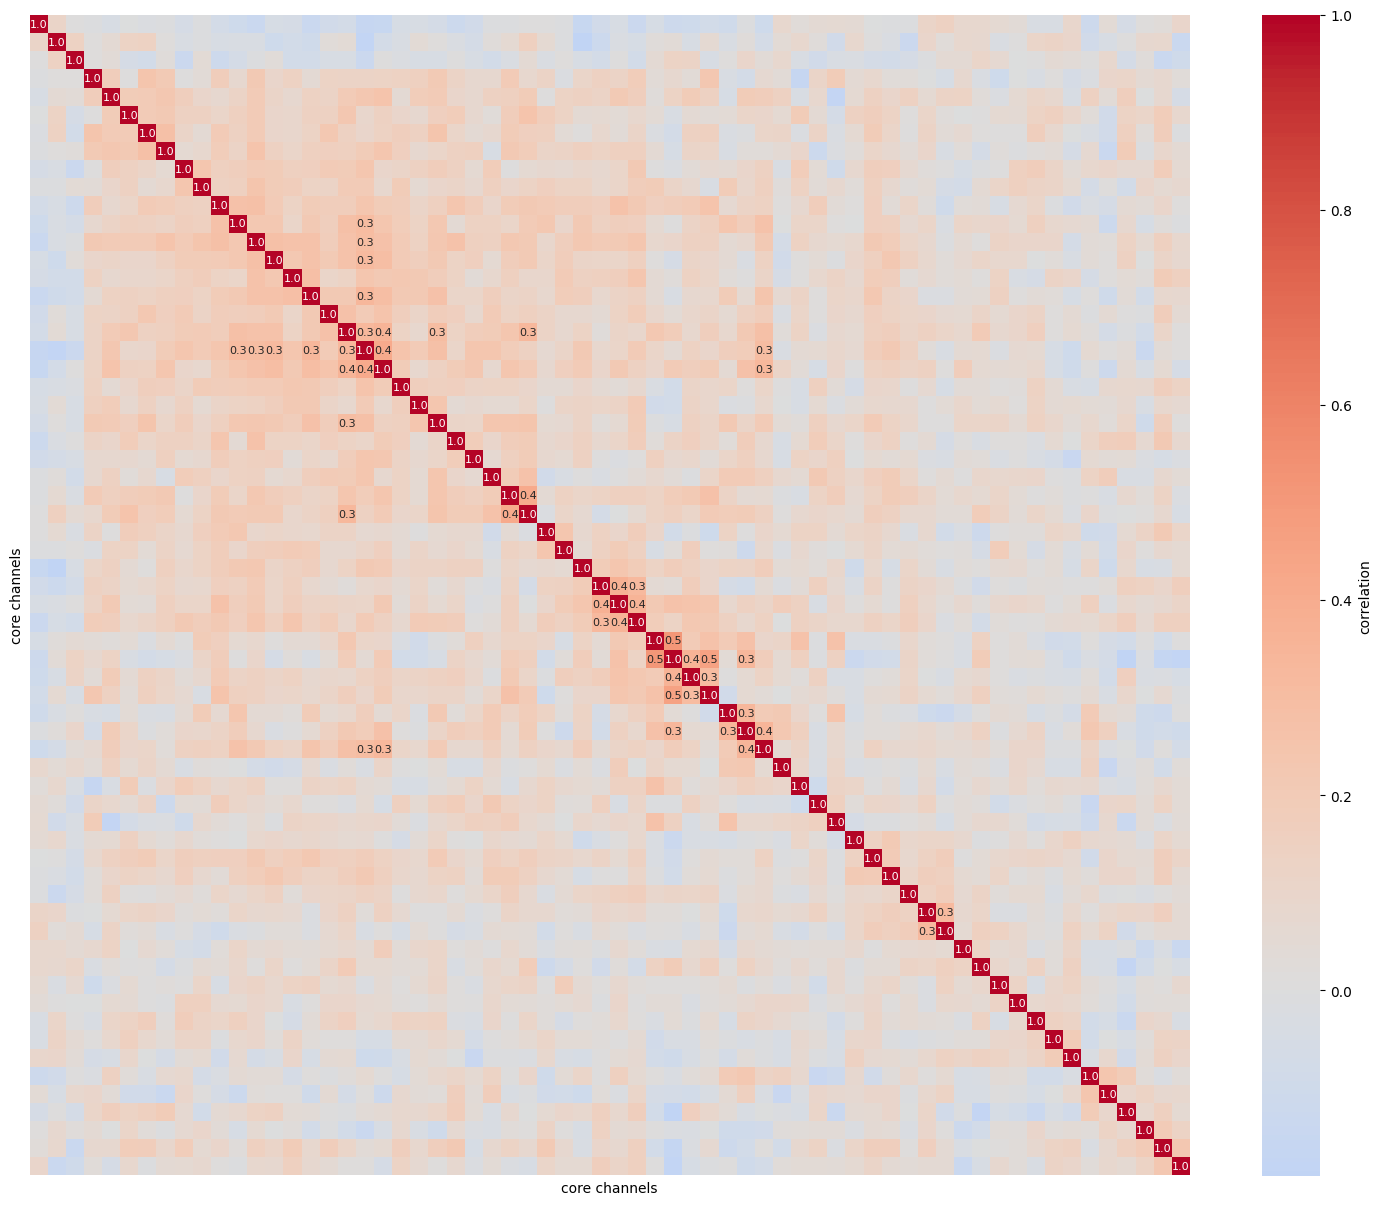

In [9]:
plt.figure(figsize=(15, 15))

#data = cov
data = corr
#data = filtered_cov
#data = filtered_corr

clustermap = sns.clustermap(data)
order = clustermap.dendrogram_row.reordered_ind

#var_idcs = cov.diag().argsort().flip(0)
#order = var_idcs
data = data[order][:, order]

plt.close()

mask = np.abs(data) < 0.3
heatmap = sns.heatmap(
    data, 
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": 0.79}, 
    annot=np.where(mask, '', np.round(data, 1)),
    fmt='', 
    annot_kws={'size': 8}, 
    xticklabels=False, 
    yticklabels=False, 
)

heatmap.set_xlabel("core channels")
heatmap.set_ylabel("core channels")
heatmap.figure.axes[-1].set_ylabel("correlation")  # The colorbar is usually the last axis

plt.tight_layout()
plt.savefig('plots/core_channel_cov.pdf')
plt.show()

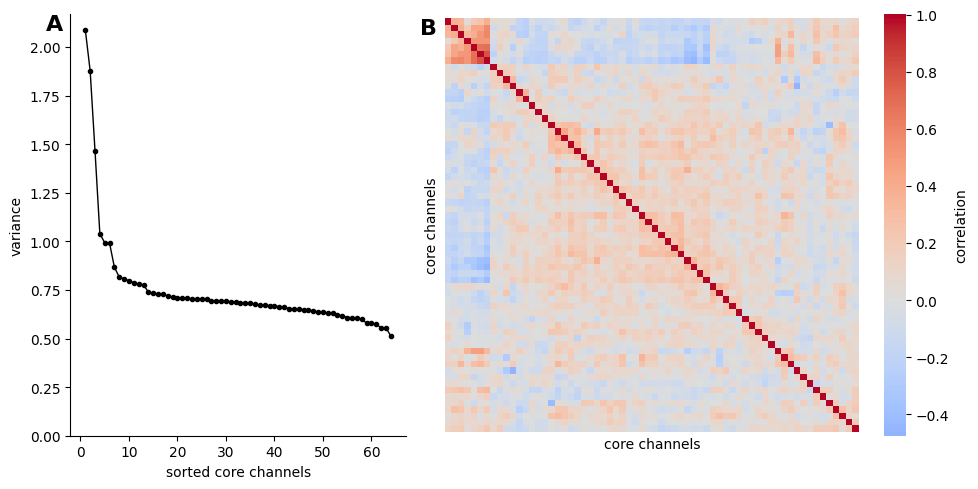

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1.3, 2]})

vals = cov.diag().sort().values.flip(0)
axs[0].plot(range(1, len(vals) + 1), vals, label='core channel variance', marker='.', lw=1, c='black')
axs[0].set_xlabel('sorted core channels')
axs[0].set_ylabel('variance')
#axs[0].grid()
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
#axs[0].set_xticks([])
axs[0].set_ylim(0)
axs[0].text(-0.02, 1, 'A', transform=axs[0].transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='right')

data = corr
clustermap = sns.clustermap(data)
order = clustermap.dendrogram_row.reordered_ind
plt.close()
data = data[order][:, order]

#data = torch.triu(data, diagonal=1)
#mask = np.abs(data) < 0.3
heatmap = sns.heatmap(
    data, 
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": 1}, 
    xticklabels=False, 
    yticklabels=False, 
)

heatmap.set_xlabel("core channels")
heatmap.set_ylabel("core channels")
heatmap.figure.axes[-1].set_ylabel("correlation")  # The colorbar is usually the last axis
axs[1].text(-0.02, 1, 'B', transform=axs[1].transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig('plots/results_base_core_channels_cov.pdf', bbox_inches='tight')
plt.show()

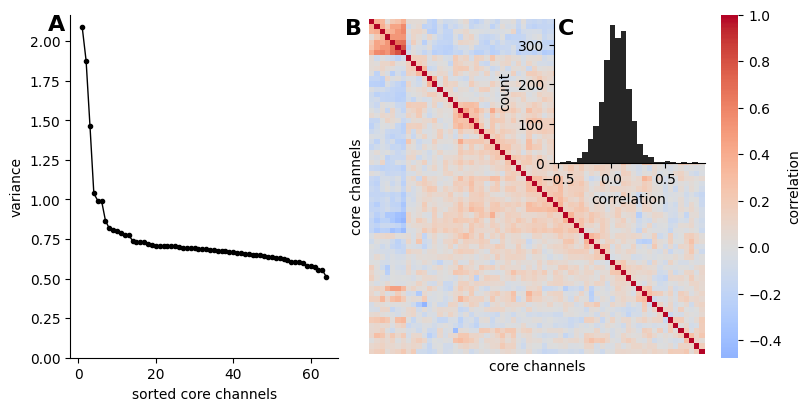

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 2, figsize=(8, 4),
                        gridspec_kw={'width_ratios': [1.6, 2]}, constrained_layout=True)

# --- A: variance curve ---
vals = cov.diag().sort().values.flip(0)
axs[0].plot(range(1, len(vals) + 1), vals, label='core channel variance',
            marker='.', lw=1, c='black')
axs[0].set_xlabel('sorted core channels')
axs[0].set_ylabel('variance')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_ylim(0)
axs[0].text(-0.02, 1, 'A', transform=axs[0].transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

# --- B: correlation heatmap (force it onto axs[1]) ---
data = corr
clustermap = sns.clustermap(data)
order = clustermap.dendrogram_row.reordered_ind
plt.close(clustermap.fig)
data = data[order][:, order]

hm = sns.heatmap(
    data,
    ax=axs[1],
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": 1},
    xticklabels=False,
    yticklabels=False,
)
axs[1].set_xlabel("core channels")
axs[1].set_ylabel("core channels")
hm.figure.axes[-1].set_ylabel("correlation")
axs[1].text(-0.02, 1, 'B', transform=axs[1].transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

# --- C: inset histogram (top-right overlay) ---
# get lower-triangular correlations (exclude diagonal)
data_np = np.asarray(data)
i, j = np.tril_indices(data_np.shape[0], k=-1)
corr_values = data_np[i, j]

axins = inset_axes(axs[1], width="45%", height="43%", loc="upper right", borderpad=0)
axins.hist(corr_values, bins=25, color="black", alpha=0.85)
axins.text(0.14, 1, 'C', transform=axins.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
#axins.set_title('C', loc='left', fontweight="bold", fontsize=16, pad=2)
axins.set_xlabel('correlation')
axins.set_ylabel('count')
#axins.set_xticks([-0.2, 0, 0.2, 0.4])
#axins.tick_params(labelsize=8)
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

#plt.tight_layout()
plt.savefig('plots/results_base_nonortho.pdf')
plt.show()

/tmp/ipykernel_534962/3928858212.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave room on the right for the colorbar


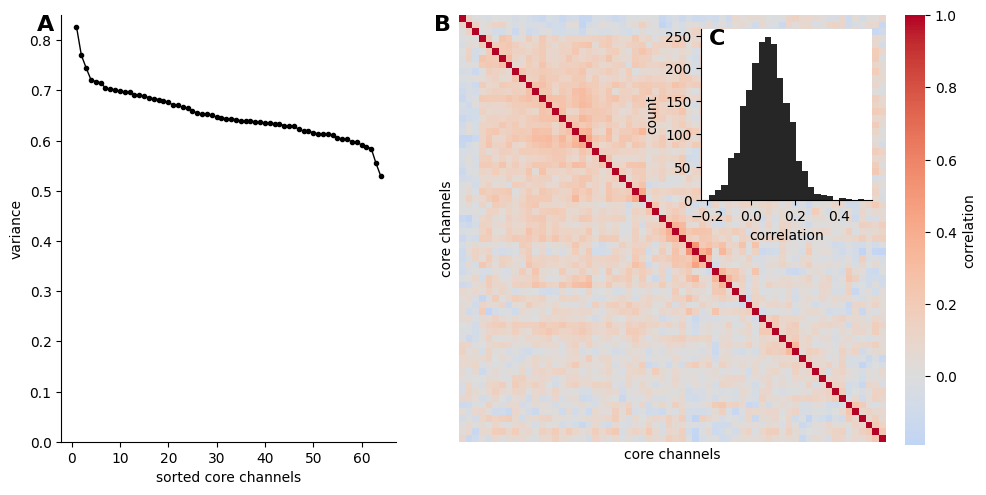

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 2, figsize=(10, 5),
                        gridspec_kw={'width_ratios': [1.3, 2]})

# --- A ---
vals = cov.diag().sort().values.flip(0)
axs[0].plot(range(1, len(vals) + 1), vals, marker='.', lw=1, c='black')
axs[0].set_xlabel('sorted core channels')
axs[0].set_ylabel('variance')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_ylim(0, 0.85)
axs[0].text(-0.02, 1, 'A', transform=axs[0].transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

# --- B ---
data = corr
cg = sns.clustermap(data)
order = cg.dendrogram_row.reordered_ind
plt.close(cg.fig)
data = data[order][:, order]

# allocate a dedicated colorbar axis next to axs[1]
pos = axs[1].get_position()
cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height + 0.09])  # right of heatmap

hm = sns.heatmap(
    data, ax=axs[1],
    cmap='coolwarm', center=0, square=True,
    cbar=True, cbar_ax=cax,                 # <-- fixed placement
    xticklabels=False, yticklabels=False,
)
axs[1].set_xlabel("core channels")
axs[1].set_ylabel("core channels")
cax.set_ylabel("correlation")

axs[1].text(-0.02, 1, 'B', transform=axs[1].transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

# --- C inset ---
data_np = np.asarray(data)
i, j = np.tril_indices(data_np.shape[0], k=-1)
corr_values = data_np[i, j]

axins = inset_axes(axs[1], width="40%", height="40%", loc="upper right", borderpad=1)
axins.hist(corr_values, bins=25, color="black", alpha=0.85)
axins.text(0.14, 1, 'C', transform=axins.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='right')
axins.set_xlabel('correlation')
axins.set_ylabel('count')
axins.set_xticks([-0.2, 0, 0.2, 0.4])
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

# Use constrained_layout OR tight_layout, not both; here tight_layout but reserve space for cax
plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave room on the right for the colorbar

plt.savefig('plots/results_base_core_channels_cov.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_527512/3194017173.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.2)


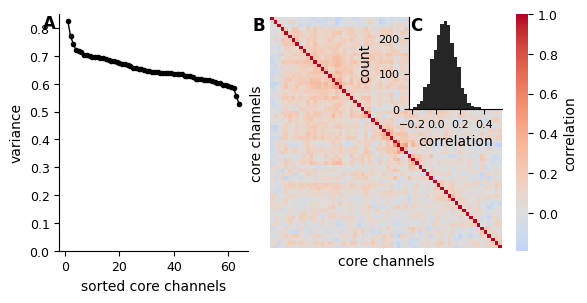

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---- Match LaTeX widths (in pt) ----
COLUMNWIDTH_PT = 418.25
PT_PER_IN = 72.27
fig_w = COLUMNWIDTH_PT / PT_PER_IN          # ~4.773 in
fig_h = fig_w * 0.5                      # choose aspect; adjust to taste

# ---- Match LaTeX font size (set to your document's target) ----
BASE_FONTSIZE_PT = 10  # set to 11 if your LaTeX is 11pt normalsize, etc.

mpl.rcParams.update({
    "font.size": BASE_FONTSIZE_PT,
    "axes.labelsize": BASE_FONTSIZE_PT,
    "axes.titlesize": BASE_FONTSIZE_PT,
    "xtick.labelsize": BASE_FONTSIZE_PT - 1,
    "ytick.labelsize": BASE_FONTSIZE_PT - 1,
    "legend.fontsize": BASE_FONTSIZE_PT - 1,
    "pdf.fonttype": 42,   # nicer embedding
    "ps.fonttype": 42,
})

fig, axs = plt.subplots(
    1, 2, figsize=(fig_w, fig_h),
    gridspec_kw={'width_ratios': [1.3, 2]}
)

# --- A: variance curve ---
vals = cov.diag().sort().values.flip(0)
axs[0].plot(range(1, len(vals) + 1), vals, marker='.', lw=1, c='black')
axs[0].set_xlabel('sorted core channels')
axs[0].set_ylabel('variance')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_ylim(0, 0.85)
axs[0].text(-0.02, 1, 'A', transform=axs[0].transAxes,
            fontsize=BASE_FONTSIZE_PT + 2, fontweight='bold', va='top', ha='right')

# --- B: correlation heatmap ---
data = corr
clustermap = sns.clustermap(data)
order = clustermap.dendrogram_row.reordered_ind
plt.close(clustermap.fig)
data = data[order][:, order]

hm = sns.heatmap(
    data, ax=axs[1],
    cmap='coolwarm', center=0, square=True,
    cbar_kws={"shrink": 1},
    xticklabels=False, yticklabels=False,
)
axs[1].set_xlabel("core channels")
axs[1].set_ylabel("core channels")
hm.figure.axes[-1].set_ylabel("correlation")
axs[1].text(-0.02, 1, 'B', transform=axs[1].transAxes,
            fontsize=BASE_FONTSIZE_PT + 2, fontweight='bold', va='top', ha='right')

# --- C: inset histogram ---
data_np = np.asarray(data)
i, j = np.tril_indices(data_np.shape[0], k=-1)
corr_values = data_np[i, j]

axins = inset_axes(axs[1], width="40%", height="40%", loc="upper right", borderpad=0)
axins.hist(corr_values, bins=25, color="black", alpha=0.85)
axins.text(0.14, 1, 'C', transform=axins.transAxes,
           fontsize=BASE_FONTSIZE_PT + 2, fontweight='bold', va='top', ha='right')
axins.set_xlabel('correlation')
axins.set_ylabel('count')
axins.set_xticks([-0.2, 0, 0.2, 0.4])
axins.tick_params(labelsize=BASE_FONTSIZE_PT - 2)
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

plt.tight_layout(pad=0.2)
plt.savefig('plots/results_base_core_channels_cov.pdf', bbox_inches='tight')
plt.show()

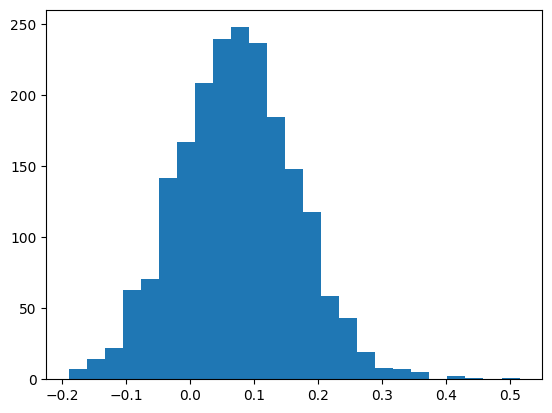

In [47]:
i, j = torch.tril_indices(data.shape[0], data.shape[1], offset=-1)
corr_values = data[i, j]

plt.hist(corr_values, bins=25)
plt.show()